# Branin–Hoo optimization with SciPy (`scipy.optimize`)

This notebook optimizes the 2‑D **Branin–Hoo** test function using:

1. **Gradient descent + regular line search** (strong Wolfe line search via `scipy.optimize.line_search`)
2. **Newton’s method + line search** (exact Hessian)
3. **Quasi‑Newton (BFGS)** using `scipy.optimize.minimize`
4. **Nonlinear conjugate gradient (Fletcher–Reeves) + line search**

It has been designed for you to use without any need for Jax or PyTorch.

For each method, we record and plot:
- objective value history $f(x_k)$
- gradient infinity‑norm history $ \|\nabla f(x_k)\|_\infty$
- the 2‑D optimization trajectory over Branin–Hoo contours


## Problem definition

The (standard) Branin–Hoo function is

\[
f(x, y) = a\,(y - b x^2 + c x - r)^2 + s(1 - t)\cos(x) + s
\]

with the conventional constants:

- \(a = 1\)
- \(b = \frac{5.1}{4\pi^2}\)
- \(c = \frac{5}{\pi}\)
- \(r = 6\)
- \(s = 10\)
- \(t = \frac{1}{8\pi}\)

A common plotting domain is \(x \in [-5, 10]\), \(y \in [0, 15]\).
The function has three global minima on that domain with value \(f^* \approx 0.397887\).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional

from numpy.linalg import norm
from scipy.optimize import line_search, minimize


## Branin–Hoo function, gradient, and Hessian

In [16]:
# Branin–Hoo constants (standard)
a = 1.0
b = 5.1 / (4.0 * np.pi**2)
c = 5.0 / np.pi
r = 6.0
s = 10.0
t = 1.0 / (8.0 * np.pi)

def branin(xy: np.ndarray) -> float:
    
    x, y = float(xy[0]), float(xy[1])
    u = y - b*x**2 + c*x - r
    return a*u**2 + s*(1.0 - t)*np.cos(x) + s

def branin_grad(xy: np.ndarray) -> np.ndarray:
    
    x, y = float(xy[0]), float(xy[1])
    u = y - b*x**2 + c*x - r
    p = (-2.0*b*x + c)          # du/dx
    dfdx = 2.0*a*u*p - s*(1.0 - t)*np.sin(x)
    dfdy = 2.0*a*u
    return np.array([dfdx, dfdy], dtype=float)

def branin_hess(xy: np.ndarray) -> np.ndarray:
    
    x, y = float(xy[0]), float(xy[1])
    u = y - b*x**2 + c*x - r
    p = (-2.0*b*x + c)
    d2f_xx = 2.0*a*(p**2 - 2.0*b*u) - s*(1.0 - t)*np.cos(x)
    d2f_xy = 2.0*a*p
    d2f_yy = 2.0*a
    return np.array([[d2f_xx, d2f_xy],
                     [d2f_xy, d2f_yy]], dtype=float)

# Known global minima (on the usual plotting box) and their objective values
global_minima = [
    np.array([-np.pi, 12.275]),
    np.array([ np.pi,  2.275]),
    np.array([ 9.42478, 2.475]),
]

for i, m in enumerate(global_minima, 1):
    print(f"min {i}: x = {m}, f(x) = {branin(m):.12f}")


min 1: x = [-3.14159265 12.275     ], f(x) = 0.397887357730
min 2: x = [3.14159265 2.275     ], f(x) = 0.397887357730
min 3: x = [9.42478 2.475  ], f(x) = 0.397887357753


## Line search helper (SciPy strong Wolfe + Armijo fallback)

In [17]:
def wolfe_line_search(
    xk: np.ndarray,
    pk: np.ndarray,
    gfk: Optional[np.ndarray] = None,
    old_fval: Optional[float] = None,
    c1: float = 1e-4,
    c2: float = 0.9,
    maxiter: int = 20,
) -> float:
    """Strong Wolfe line search via SciPy, with a simple backtracking fallback.

    Returns a positive step length alpha.
    """
    xk = np.asarray(xk, dtype=float)
    pk = np.asarray(pk, dtype=float)

    if gfk is None:
        gfk = branin_grad(xk)
    if old_fval is None:
        old_fval = branin(xk)

    ls = line_search(
        branin, branin_grad, xk, pk,
        gfk=gfk, old_fval=old_fval,
        c1=c1, c2=c2, maxiter=maxiter
    )
    alpha = ls[0]
    if alpha is not None and alpha > 0:
        return float(alpha)

    # Fallback: Armijo backtracking (only used if SciPy line_search fails)
    alpha = 1.0
    phi0 = old_fval
    derphi0 = float(np.dot(gfk, pk))

    # If pk is not descent, flip to steepest descent
    if derphi0 >= 0:
        pk = -gfk
        derphi0 = float(np.dot(gfk, pk))

    for _ in range(30):
        if branin(xk + alpha*pk) <= phi0 + c1*alpha*derphi0:
            return float(alpha)
        alpha *= 0.5
        if alpha < 1e-12:
            break
    return float(alpha)


## Optimization algorithms

In [19]:
def optimize_gradient_descent_linesearch(
    x0: np.ndarray,
    tol: float = 1e-6,
    max_iter: int = 200,
):
    """Steepest descent with (strong Wolfe) line search."""
    xk = np.asarray(x0, dtype=float)
    xs = [xk.copy()]
    fs = [branin(xk)]
    ginf = [norm(branin_grad(xk), ord=np.inf)]
    alphas = []

    for _ in range(max_iter):
        gk = branin_grad(xk)
        if norm(gk, ord=np.inf) < tol:
            break
        pk = -gk
        alpha = wolfe_line_search(xk, pk, gfk=gk, old_fval=fs[-1])
        alphas.append(alpha)

        xk = xk + alpha*pk
        xs.append(xk.copy())
        fs.append(branin(xk))
        ginf.append(norm(branin_grad(xk), ord=np.inf))

    return {
        "method": "Gradient descent + line search",
        "x": np.array(xs),
        "f": np.array(fs),
        "ginf": np.array(ginf),
        "alphas": np.array(alphas),
    }


def optimize_newton_linesearch(
    x0: np.ndarray,
    tol: float = 1e-6,
    max_iter: int = 50,
):
    """Newton's method with (strong Wolfe) line search."""
    xk = np.asarray(x0, dtype=float)
    xs = [xk.copy()]
    fs = [branin(xk)]
    ginf = [norm(branin_grad(xk), ord=np.inf)]
    alphas = []

    for _ in range(max_iter):
        gk = branin_grad(xk)
        if norm(gk, ord=np.inf) < tol:
            break

        Hk = branin_hess(xk)

        # Newton direction (fallback to -grad if singular or not descent)
        try:
            pk = -np.linalg.solve(Hk, gk)
        except np.linalg.LinAlgError:
            pk = -gk

        if float(np.dot(gk, pk)) >= 0:
            pk = -gk

        alpha = wolfe_line_search(xk, pk, gfk=gk, old_fval=fs[-1])
        alphas.append(alpha)

        xk = xk + alpha*pk
        xs.append(xk.copy())
        fs.append(branin(xk))
        ginf.append(norm(branin_grad(xk), ord=np.inf))

    return {
        "method": "Newton + line search",
        "x": np.array(xs),
        "f": np.array(fs),
        "ginf": np.array(ginf),
        "alphas": np.array(alphas),
    }


def optimize_fletcher_reeves_cg(
    x0: np.ndarray,
    tol: float = 1e-6,
    max_iter: int = 200,
):
    """Nonlinear conjugate gradient (Fletcher–Reeves) with line search."""
    xk = np.asarray(x0, dtype=float)
    gk = branin_grad(xk)
    pk = -gk

    xs = [xk.copy()]
    fs = [branin(xk)]
    ginf = [norm(gk, ord=np.inf)]
    alphas = []
    betas = []

    n = xk.size

    for k in range(max_iter):
        if norm(gk, ord=np.inf) < tol:
            break

        alpha = wolfe_line_search(xk, pk, gfk=gk, old_fval=fs[-1])
        alphas.append(alpha)

        x_next = xk + alpha*pk
        g_next = branin_grad(x_next)

        denom = float(np.dot(gk, gk))
        denom = max(denom, 1e-300)
        beta = float(np.dot(g_next, g_next) / denom)
        betas.append(beta)

        p_next = -g_next + beta*pk

        # Restart if direction is not descent (or periodically every n iterations)
        if float(np.dot(g_next, p_next)) >= 0:
            p_next = -g_next
        if (k + 1) % n == 0:
            p_next = -g_next

        xk, gk, pk = x_next, g_next, p_next

        xs.append(xk.copy())
        fs.append(branin(xk))
        ginf.append(norm(gk, ord=np.inf))

    return {
        "method": "Conjugate gradient (Fletcher–Reeves) + line search",
        "x": np.array(xs),
        "f": np.array(fs),
        "ginf": np.array(ginf),
        "alphas": np.array(alphas),
        "betas": np.array(betas),
    }


## Quasi‑Newton via SciPy (`minimize(method='BFGS')`)

In [20]:
def optimize_bfgs_scipy(
    x0: np.ndarray,
    tol: float = 1e-6,
    max_iter: int = 200,
):
    """SciPy BFGS with history captured via callback."""
    x0 = np.asarray(x0, dtype=float)

    xs = [x0.copy()]
    fs = [branin(x0)]
    ginf = [norm(branin_grad(x0), ord=np.inf)]

    def cb(xk):
        xk = np.asarray(xk, dtype=float)
        xs.append(xk.copy())
        fs.append(branin(xk))
        ginf.append(norm(branin_grad(xk), ord=np.inf))

    res = minimize(
        branin, x0, jac=branin_grad, method="BFGS",
        callback=cb,
        options={"gtol": tol, "maxiter": max_iter, "disp": False},
    )

    return {
        "method": "BFGS (SciPy)",
        "x": np.array(xs),
        "f": np.array(fs),
        "ginf": np.array(ginf),
        "scipy_result": res,
    }


## Run all methods from the same starting point

In [21]:
x0 = np.array([2.0, 10.0])   # starting point (feel free to change)

tol = 1e-6

results = []
results.append(optimize_gradient_descent_linesearch(x0, tol=tol, max_iter=300))
results.append(optimize_newton_linesearch(x0, tol=tol, max_iter=50))
results.append(optimize_bfgs_scipy(x0, tol=tol, max_iter=200))
results.append(optimize_fletcher_reeves_cg(x0, tol=tol, max_iter=300))

for r in results:
    print(f"{r['method']}: iters={len(r['f'])-1:3d}, x*={r['x'][-1]}, f*={r['f'][-1]:.12f}, ||g||_inf={r['ginf'][-1]:.3e}")


Gradient descent + line search: iters= 44, x*=[3.1415925  2.27500056], f*=0.397887357730, ||g||_inf=8.845e-07
Newton + line search: iters=  5, x*=[9.42477796 2.475     ], f*=0.397887357730, ||g||_inf=3.273e-12
BFGS (SciPy): iters=  8, x*=[3.14159265 2.27499999], f*=0.397887357730, ||g||_inf=9.126e-08
Conjugate gradient (Fletcher–Reeves) + line search: iters= 14, x*=[9.42477796 2.475     ], f*=0.397887357730, ||g||_inf=8.099e-09


## Summary table

In [22]:
import pandas as pd
# Let us illustrate the use of Pandas to store optimization output stats

summary = []
for r in results:
    summary.append({
        "method": r["method"],
        "iterations": len(r["f"]) - 1,
        "x_final": r["x"][-1],
        "f_final": r["f"][-1],
        "grad_inf_final": r["ginf"][-1],
    })

pd.DataFrame(summary)


,method,iterations,x_final,f_final,grad_inf_final
0,Gradient descent + line search,44,"[3.1415924966761333, 2.275000564634387]",0.397887,8.845276e-07
1,Newton + line search,5,"[9.424777960768804, 2.4749999999981744]",0.397887,3.273342e-12
2,BFGS (SciPy),8,"[3.141592645919104, 2.2749999946955994]",0.397887,9.125852e-08
3,Conjugate gradient (Fletcher–Reeves) + line se...,14,"[9.424777960779627, 2.4750000040582214]",0.397887,8.099157e-09


## Objective history

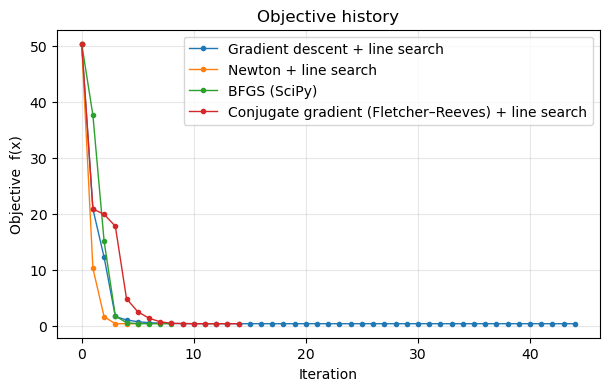

In [23]:
plt.figure(figsize=(7, 4))
for r in results:
    plt.plot(r["f"], marker="o", markersize=3, linewidth=1, label=r["method"])
plt.xlabel("Iteration")
plt.ylabel("Objective  f(x)")
plt.title("Objective history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Gradient infinity‑norm history

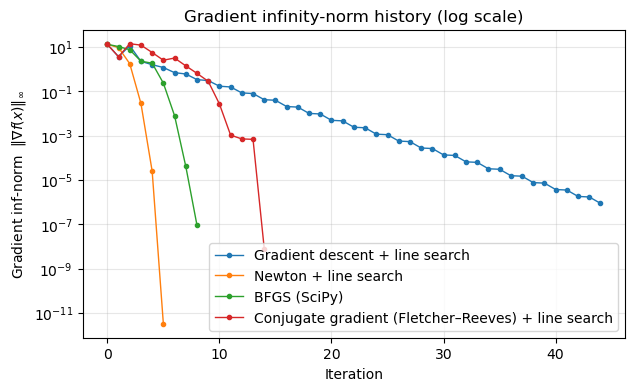

In [24]:
plt.figure(figsize=(7, 4))
for r in results:
    plt.semilogy(r["ginf"], marker="o", markersize=3, linewidth=1, label=r["method"])
plt.xlabel("Iteration")
plt.ylabel(r"Gradient inf-norm  $\|\nabla f(x)\|_\infty$")
plt.title("Gradient infinity-norm history (log scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


## Optimization trajectories on Branin–Hoo contours

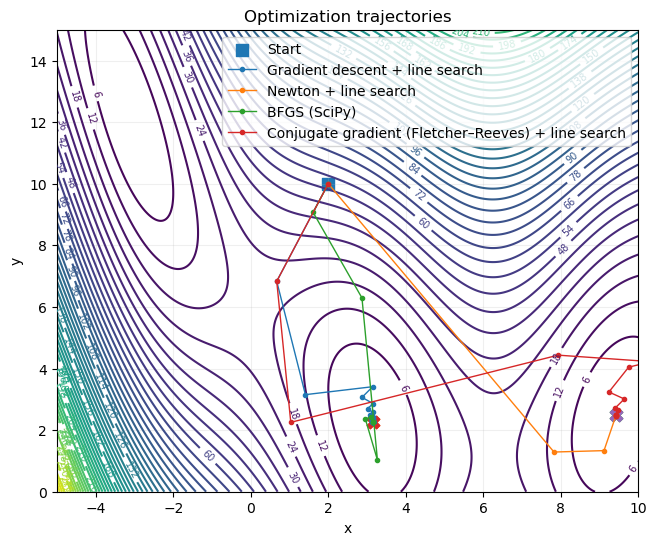

In [25]:

# Build a contour grid on the typical Branin plotting domain
x1 = np.linspace(-5, 10, 400)
x2 = np.linspace(0, 15, 400)
X1, X2 = np.meshgrid(x1, x2)

# Branin constants (reset to ensure no overwriting)
a = 1.0
b = 5.1 / (4 * np.pi**2)
c = 5.0 / np.pi
r = 6.0
s = 10.0
t = 1.0 / (8 * np.pi)

Z = a*(X2 - b*X1**2 + c*X1 - r)**2 + s*(1.0 - t)*np.cos(X1) + s

plt.figure(figsize=(7.5, 6))
cs = plt.contour(X1, X2, Z, levels=60)
plt.clabel(cs, inline=1, fontsize=7, fmt="%.0f")

# Plot start point
plt.scatter([x0[0]], [x0[1]], marker="s", s=80, label="Start")

# Plot known global minima
mins = np.array(global_minima)
# plt.scatter(mins[:, 0], mins[:, 1], marker="*", s=120, label="Known global minima")

# Plot trajectories (and final points)
for r in results:
    xs = r["x"]
    plt.plot(xs[:, 0], xs[:, 1], marker="o", markersize=3, linewidth=1, label=r["method"])
    plt.scatter([xs[-1, 0]], [xs[-1, 1]], marker="X", s=80)

plt.xlim(-5, 10)
plt.ylim(0, 15)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimization trajectories")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)
plt.show()
